In [3]:
# =======================================================================================
#                       Etape 1 : Préparation et Transformation
# =======================================================================================

In [4]:
# ==================================
# 1. Importation des bibliothèques
# ==================================
from google.cloud import bigquery
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [5]:
# =========================================
# 2. Chargement et exploration des données
# =========================================
# Charger le dataset

client = bigquery.Client.from_service_account_json("key.json")

query = """
    SELECT
    *
    FROM `project-a0475dd2-d0c1-4640-aea.Sport_Metrics.mart_physical_condition`
"""

# Executer la requete
query_job = client.query(query)

# Transformer en dataframe
data = query_job.to_dataframe()

# Aperçu des premières lignes
print("Aperçu des données :\n", data.head())

# Informations générales sur les colonnes et les types de données
print("\nInformations sur le dataset :")
print(data.info())

# Statistiques descriptives
print("\nStatistiques descriptives :")
print(data.describe())

C:\Users\fafap\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Aperçu des données :
       Season   player_id                        session_id  Next_Match_ID  \
0  2019-2020  1681114057  FFS_20191020_1681114057_21900010       21900010   
1  2019-2020  1684823847  FFS_20191021_1684823847_21900010       21900010   
2  2019-2020  1681114057  FFS_20191021_1681114057_21900010       21900010   
3  2019-2020  1679015727  FFS_20191021_1679015727_21900010       21900010   
4  2019-2020  1657985451  FFS_20191021_1657985451_21900010       21900010   

      player_name  fi_last_training  rs_last_training  \
0    Abdoulaye Ba             55.11              3.01   
1  Yanis Belkacem             55.33              1.10   
2    Abdoulaye Ba             56.88              2.06   
3  Bryan Fournier             58.30              2.08   
4   Pierre Martin             61.32              0.96   

   recovery_needed_last_training  Fi_before_match  Focus_Level  ...  fg3_pct  \
0                              0             0.00          8.0  ...    0.000   
1           

In [6]:
# ==================================
# 3. Gestion des valeurs manquantes
# ==================================
# Vérification des valeurs manquantes
print(data.isnull().sum())

Season                           0
player_id                        0
session_id                       0
Next_Match_ID                    0
player_name                      0
fi_last_training                 0
rs_last_training                 0
recovery_needed_last_training    0
Fi_before_match                  0
Focus_Level                      0
Strength_Score                   0
Shooting_Accuracy_pct            0
Passing_Accuracy_pct             0
Performance_Score                0
Load_Intensity_Score             0
Injury_Risk                      0
fi_avg_7d                        0
fi_max_7d                        0
training_load_7d                 0
fi_avg_28d                       0
fi_max_28d                       0
training_load_28d                0
Place                            0
Position                         0
Start_position                   0
minutes_played                   0
Points                           0
fg_pct                           0
fg3_pct             

In [7]:
# ==================================================
# 4. Selection et nettoyage des données pertinentes
# ==================================================
# Sélection des données pertinentes
data["ACWR"] = data["fi_avg_7d"] / data["fi_avg_28d"]
df = data[data["Season"] == '2023-2024']

# Aperçu des premières lignes
print("Aperçu des données pertinentes :\n", df.head())

Aperçu des données pertinentes :
          Season   player_id                        session_id  Next_Match_ID  \
5883  2023-2024  1659116774  FFS_20231107_1659116774_22300013       22300013   
5884  2023-2024  1659116774  FFS_20231108_1659116774_22300013       22300013   
5885  2023-2024  1664883672  FFS_20231107_1664883672_22300013       22300013   
5886  2023-2024  1664883672  FFS_20231108_1664883672_22300013       22300013   
5887  2023-2024  1655322242  FFS_20231108_1655322242_22300013       22300013   

          player_name  fi_last_training  rs_last_training  \
5883   Kevin Rousseau             50.69              2.26   
5884   Kevin Rousseau             56.30              1.27   
5885  Zacharie Dupont             59.62              2.33   
5886  Zacharie Dupont             57.66              1.91   
5887  Douglas Hermans             64.36              1.16   

      recovery_needed_last_training  Fi_before_match  Focus_Level  ...  \
5883                              0         

In [8]:
# =======================================================================================
#                       Etape 2 : Data Mining
# =======================================================================================

In [9]:
# =============================================================
#                     Clustering by K-Means
# =============================================================

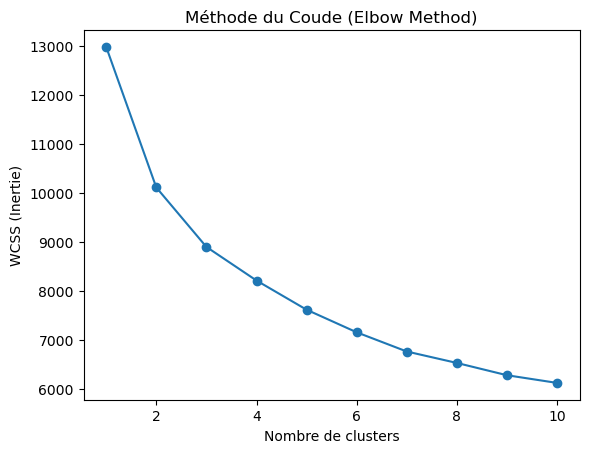

In [10]:
# Profilage de joueurs

# 1. Sélection des stats de profilage
features = ["Points","Assists","Total_rebounds","Steals","Blocks","Turnover",
            "Player_fault","Plus_minus"]
X = df[features].dropna()

# 2. Normalisation (Etape CRUCIALE pour le K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Trouver le nombre optimal de groupes (Méthode du Coude)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Méthode du Coude (Elbow Method)')
plt.xlabel('Nombre de clusters')
plt.ylabel('WCSS (Inertie)')
plt.show()

In [11]:
# 4. Initialisation de K-Means avec 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# 5. Ajustement du modèle et prédiction des clusters
df['Profil'] = kmeans.fit_predict(X_scaled) # On réattribue au DF d'origine

# 6. Affichage des moyennes par groupe pour interpréter
df.groupby('Profil')[features].mean()

C:\Users\fafap\AppData\Local\Temp\ipykernel_6484\3543244134.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Profil'] = kmeans.fit_predict(X_scaled) # On réattribue au DF d'origine


,Points,Assists,Total_rebounds,Steals,Blocks,Turnover,Player_fault,Plus_minus
Profil,,,,,,,,
0,14.499192,4.387722,5.056543,0.927302,0.44588,1.875606,2.248788,-2.626817
1,21.0,3.802721,11.680272,1.306122,3.47619,3.707483,2.278912,-0.238095
2,6.257876,1.686114,2.352392,0.381564,0.233372,0.665111,1.117853,-4.378063


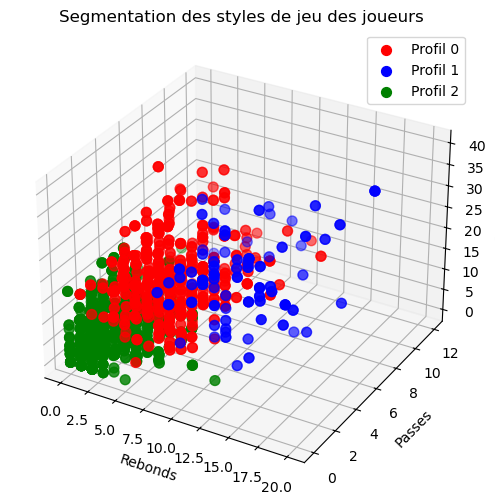

In [12]:
# 7. Visualisation des clusters Rebonds + Passes + Steals
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'blue', 'green', 'yellow']
for i in range(3):
    cluster_data = df[df['Profil'] == i]
    ax.scatter(cluster_data['Total_rebounds'], cluster_data['Assists'], cluster_data['Points'], 
               c=colors[i], label=f'Profil {i}', s=50)

ax.set_xlabel('Rebonds')
ax.set_ylabel('Passes')
ax.set_zlabel('Points')
plt.legend()
plt.title('Segmentation des styles de jeu des joueurs')
plt.show()

Profils probables :

Profil 0 : Lieutenant All-Star => Arrière voir Exterieur

Stats clés : 14.49 pts, 4.38 assists (le plus haut).

Style : Créateurs. A protéger via le Load Management

Profil 1 : Super star, seul dans son cluster => Le Pivot dominant / Protecteur de cercle 
Stats clés : 21 pts, 11.68 rebonds, 3.47 blocks.

Style : Meilleurs marqueurs, rebondeurs, et contreur. Le murasakibara de l'équipe. mais perd beaucoup de ballons.

A proteger en load management et travailler la conservation du ballon

Profil 2 : Les Spécialiste du Banc

Stats clés : 6.26 pts, plus minus -4,37.

Style : Probablement les recrues issues de la Draft récente. Ils ont un faible impact statistique pour le moment

In [13]:
# 8. Afficher le nombre de joueur par profil (Cluster)
player_cluster = (df.groupby("player_name")["Profil"].agg(
    lambda x: x.value_counts().index[0]
))

player_cluster.value_counts().sort_index()

Profil
0     6
1     1
2    13
Name: count, dtype: int64

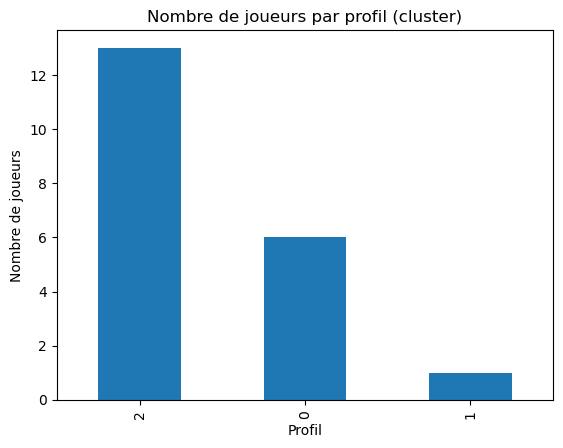

In [14]:
player_cluster.value_counts().plot(kind="bar")

plt.title("Nombre de joueurs par profil (cluster)")
plt.xlabel("Profil")
plt.ylabel("Nombre de joueurs")
plt.show()

In [15]:
# Afficher les profils des joueurs et leur performances individuelles en match
player_cluster = player_cluster.reset_index()

player_stats = (df.groupby("player_name")[["Plus_minus","Points","Total_rebounds",
                                           "Assists","Blocks","Steals","minutes_played"
                                          ]].mean().reset_index())

player_cluster = player_cluster.merge(player_stats, on="player_name")
player_cluster.sort_values("Profil")

,player_name,Profil,Plus_minus,Points,Total_rebounds,Assists,Blocks,Steals,minutes_played
7,Jamil Azizi,0,6.666667,4.0,5.666667,1.666667,0.0,0.333333,18.980000
11,Lucas Dubois,0,-5.233871,15.266129,5.387097,2.790323,0.282258,0.766129,29.737097
10,Kevin Rousseau,0,-4.979730,19.445946,3.824324,4.013514,0.371622,1.040541,33.144730
9,Jérémie Kowalski,0,-5.163121,11.836879,6.503546,3.368794,0.510638,0.822695,29.516879
19,Zacharie Dupont,0,-5.765152,11.098485,5.30303,2.742424,0.757576,0.469697,21.858333
17,Théo Garnier,0,-0.317568,9.716216,3.918919,6.135135,0.141892,0.993243,27.548446
18,Vincent Beaumont,1,-1.882353,21.382353,10.720588,3.852941,3.522059,1.183824,29.546985
3,David Roussel,2,2.333333,7.666667,3.333333,1.333333,0.0,0.666667,16.043333
6,Douglas Hermans,2,-3.825581,5.744186,0.953488,1.267442,0.034884,0.244186,15.191744
5,Dominique Faure,2,-0.607843,5.137255,3.901961,1.392157,0.529412,0.490196,15.193529


In [16]:
# Afficher la position et la performance en match des joueurs par profil

player_cluster = (df.groupby(["player_name"])
                  ["Profil"].agg(lambda x: x.value_counts().index[0]).reset_index()
                 )

# Pour savoir qui débute sur le terrain et qui est sur le banc
player_position = ( df.groupby(["player_name"])
                   [["Position","Start_position"]].agg(
                       lambda x: x.value_counts().index[0]
                   ).reset_index()
                  )

# Pour voir leur performance en match
player_perf = (df.groupby(["player_name"])
               ["Performance_score_match"].mean().reset_index()
              )
# Assembler pour afficher les infos dans le même tableau
player_cluster = player_cluster.merge(player_position, on=["player_name"])
player_cluster = player_cluster.merge(player_perf, on=["player_name"])

player_cluster

,player_name,Profil,Position,Start_position,Performance_score_match
0,Blaise Schneider,2,Guard,Bench,7.678899
1,Charles Diouf,2,Center-Forward,Bench,9.466667
2,Cédric Yilmaz,2,Forward,Bench,9.178295
3,David Roussel,2,Guard,Bench,10.666667
4,Devon Palmier,2,Guard,Bench,7.636364
5,Dominique Faure,2,Forward,Bench,9.313725
6,Douglas Hermans,2,Forward,Bench,6.755814
7,Jamil Azizi,0,Guard,Bench,7.666667
8,Julien Leroux,2,Forward,F,11.0
9,Jérémie Kowalski,0,Forward,F,18.808511


In [17]:
# Afficher que les Top Profils
top_clusters = player_cluster[player_cluster["Profil"].isin([0,1])]
top_clusters

,player_name,Profil,Position,Start_position,Performance_score_match
7,Jamil Azizi,0,Guard,Bench,7.666667
9,Jérémie Kowalski,0,Forward,F,18.808511
10,Kevin Rousseau,0,Guard-Forward,G,25.972973
11,Lucas Dubois,0,Forward-Guard,Bench,20.895161
17,Théo Garnier,0,Guard,G,18.182432
18,Vincent Beaumont,1,Forward-Center,C,34.801471
19,Zacharie Dupont,0,Forward-Center,Bench,15.454545


Lucas Dubois (Profil 0 - Le "6ème Homme" sous-estimé) : profil le plus intéressant. Bien que classé en "Bench" (Remplaçant), il appartient au cluster des stars (0). Avec un score de 20.9 en sortie de banc (plus que d'autres titulaires), il est le candidat idéal pour intégrer le 5 de départ ou obtenir plus de responsabilités.

Vincent Beaumont (Profil 1 - Pivot dominant) : Avec un score de performance de 34.80, c'est le joueur le plus impactant. Son profil correspond à l'Axe 3 sur l'impact physique : en tant que Centre (C), sa domination aux rebonds et aux contres en fait le pilier de la défense.